In [1]:
from init_env import cfg
import os
import pandas as pd
import cv2
from dataset import map_ethnicity
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = cfg["paths"]["data_path"]

catalog = pd.read_csv(os.path.join(DATA_PATH, "catalog.csv"))
catalog.head()

,dataset,patient_id,original_path,processed_path,laterality,view,pathology
0,cbis_ddsm,cbis_ddsm_P_00047,cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.391876...,cbis_ddsm/cbis_ddsm_P_00047_U_U_4d1026b0.png,U,U,malignant
1,cbis_ddsm,cbis_ddsm_P_01682,cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.379825...,cbis_ddsm/cbis_ddsm_P_01682_U_U_d148d0ae.png,U,U,malignant
2,cbis_ddsm,cbis_ddsm_P_00119,cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.162472...,cbis_ddsm/cbis_ddsm_P_00119_U_U_87fd97ae.png,U,U,benign
3,cbis_ddsm,cbis_ddsm_P_01809,cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.390096...,cbis_ddsm/cbis_ddsm_P_01809_U_U_1fec112e.png,U,U,malignant
4,cbis_ddsm,cbis_ddsm_P_00972,cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.384230...,cbis_ddsm/cbis_ddsm_P_00972_U_U_dfb5943f.png,U,U,malignant


Total images: 32191
Unique patients: 10079
Source datasets: dataset
vindr        20000
cmmd          5202
cbis_ddsm     2857
kau_bcmd      2378
dmid          1022
inbreast       410
mini_mias      322
Name: count, dtype: int64


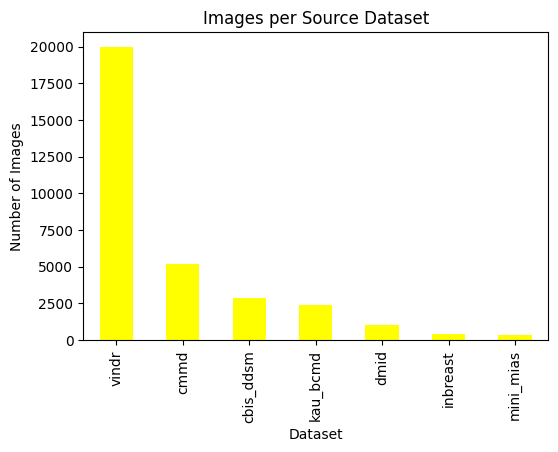

In [3]:
print("Total images:", len(catalog))
print("Unique patients:", catalog['patient_id'].nunique())
dataset_counts = catalog['dataset'].value_counts()
print("Source datasets:", dataset_counts)

plt.figure(figsize=(6,4))
dataset_counts.plot(kind='bar', color=['yellow'])
plt.title("Images per Source Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.show()

pathology
normal       20841
malignant     6873
benign        4407
unknown         70
Name: count, dtype: int64


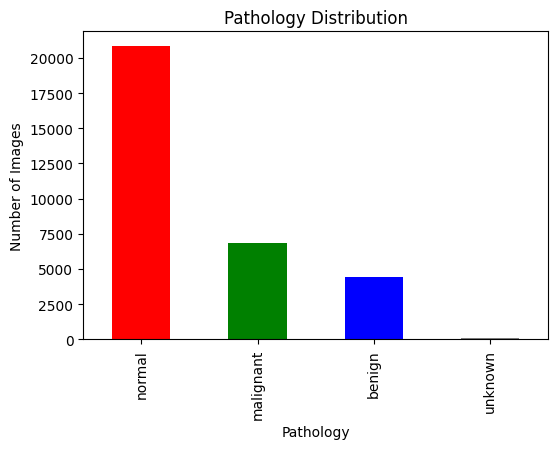

In [4]:
# Pathology distribution
pathology_counts = catalog['pathology'].value_counts()
print(pathology_counts)

plt.figure(figsize=(6,4))
pathology_counts.plot(kind='bar', color=['red','green','blue','gray'])
plt.title("Pathology Distribution")
plt.xlabel("Pathology")
plt.ylabel("Number of Images")
plt.show()

laterality
U    29403
R     1396
L     1392
Name: count, dtype: int64


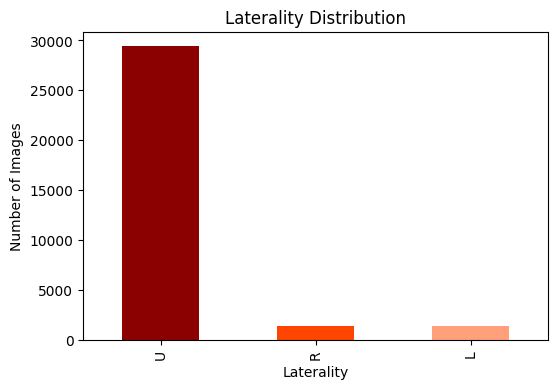

In [5]:
laterality_counts = catalog['laterality'].value_counts()
print(laterality_counts)

plt.figure(figsize=(6,4))
laterality_counts.plot(kind='bar', color=['#8B0000', '#FF4500', '#FFA07A'])
plt.title("Laterality Distribution")
plt.xlabel("Laterality")
plt.ylabel("Number of Images")
plt.show()

view
U      27212
CC      3598
MLO     1188
ML       193
Name: count, dtype: int64


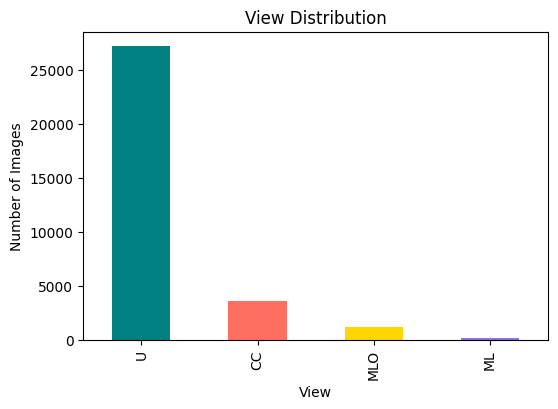

In [6]:
# View counts
view_counts = catalog['view'].value_counts()
print(view_counts)

plt.figure(figsize=(6,4))
view_counts.plot(kind='bar', color=['#008080', '#FF6F61', '#FFD700', '#9370DB'])
plt.title("View Distribution")
plt.xlabel("View")
plt.ylabel("Number of Images")
plt.show()

count    10079.000000
mean         3.193868
std          1.133357
min          1.000000
25%          2.000000
50%          4.000000
75%          4.000000
max          6.000000
dtype: float64


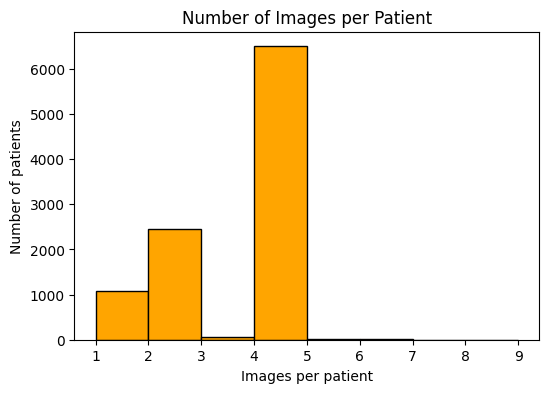

In [7]:
images_per_patient = catalog.groupby('patient_id').size()
print(images_per_patient.describe())

plt.figure(figsize=(6,4))
plt.hist(images_per_patient, bins=range(1,10), color='orange', edgecolor='black')
plt.title("Number of Images per Patient")
plt.xlabel("Images per patient")
plt.ylabel("Number of patients")
plt.show()

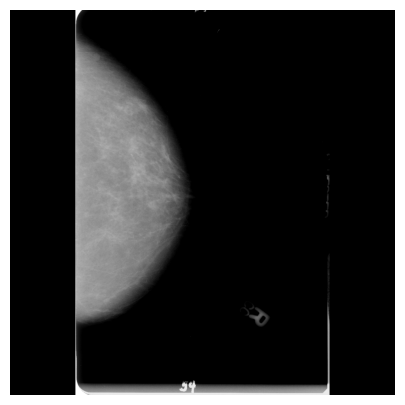

In [8]:
# Display sample image
malignant_row = catalog[catalog["pathology"].str.lower() == "malignant"].iloc[0]
malignant_path = os.path.join(DATA_PATH, "processed", malignant_row["processed_path"])

# Load images in color to check if they are in grayscale
malignant_img = cv2.imread(malignant_path, cv2.IMREAD_COLOR)

 # Display side by side
plt.figure(figsize=(15,5))

plt.imshow(malignant_img, cmap='gray')
plt.axis("off")

plt.show()

pathology
normal       20841
malignant     6873
benign        4407
Name: count, dtype: int64


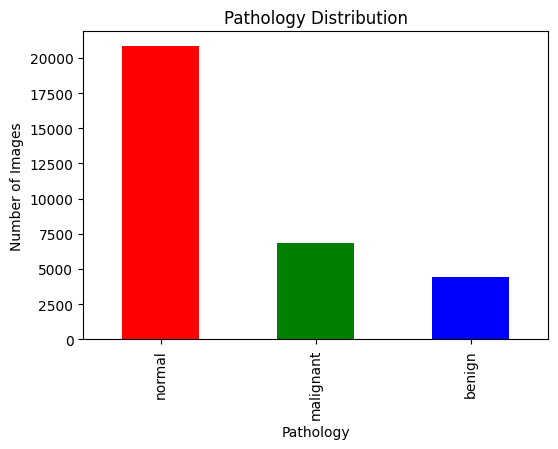

In [9]:
# Remove unknown-label images
catalog = catalog[catalog["pathology"] != "unknown"]

# Pathology distribution
pathology_counts = catalog['pathology'].value_counts()
print(pathology_counts)

plt.figure(figsize=(6,4))
pathology_counts.plot(kind='bar', color=['red','green','blue'])
plt.title("Pathology Distribution")
plt.xlabel("Pathology")
plt.ylabel("Number of Images")
plt.show()

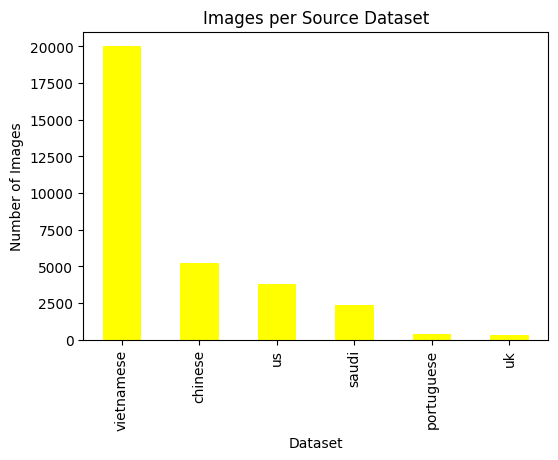

In [10]:
catalog = map_ethnicity(catalog)
dataset_counts = catalog['ethnicity'].value_counts()

plt.figure(figsize=(6,4))
dataset_counts.plot(kind='bar', color=['yellow'])
plt.title("Images per Source Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.show()